In [1]:
# ── Cài đặt dependencies ─────────────────────────────────────────
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
!pip install numpy seaborn pandas matplotlib tqdm scikit-learn -q


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Imports & GPU check
# ════════════════════════════════════════════════════════════════
import copy, time, json, warnings, shutil
import torch.nn.functional as F
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(123)
np.random.seed(123
)

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch : 2.5.1+cu121
Device  : cuda
GPU     : NVIDIA GeForce RTX 3060
VRAM    : 12.5 GB


In [3]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — Config tổng hợp (chỉ cần sửa ở đây)
# ════════════════════════════════════════════════════════════════

# ── Paths ───────────────────────────────────────────────────────
DRIVE_FOLDER = Path('/workspace/data')
OUT_DIR      = Path('/workspace/data')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset ──────────────────────────────────────────────────────
SLEEP_STAGES  = ['W', 'N1', 'N2', 'N3', 'REM']
N_CLASSES     = 5
EPOCH_SAMPLES = 3000          # 30 s × 100 Hz
N_FOLDS       = 10
MANIP_SETS    = ['A', 'B', 'C']

# ── CNN hyperparams (giữ nguyên theo paper) ──────────────────────
CNN_LR             = 1e-3
CNN_BATCH_SIZE     = 64
CNN_MAX_EPOCHS     = 1000
CNN_PATIENCE       = 10
CNN_VALIDATE_EVERY = 150
CNN_TRAIN_RATIO    = 0.70

# ── Conformer hyperparams ───────────────────────────────────────
CONF_DIM       = 128          # model dimension (d_model)
CONF_HEADS     = 4            # MHSA heads  (head_dim = 128/4 = 32)
CONF_FF_MUL    = 4            # FFN expansion factor  (128→512→128)
CONF_CONV_K    = 31           # depthwise conv kernel (covers ±15 epochs)
CONF_BLOCKS    = 2            # number of Conformer blocks
CONF_DROPOUT   = 0.1          # dropout throughout



SEQ_LR         = 2e-4         # AdamW (Conformer sensitive to lr; slightly lower than TCN)
SEQ_BATCH_SIZE = 4
SEQ_MAX_EPOCHS = 1000
SEQ_PATIENCE   = 45           # TCN converge stable, patience cao hơn
SEQ_VAL_EVERY  = 10
SEQ_VAL_RATIO  = 0.10
WARMUP_ITERS   = 100          # warmup ngắn cho TCN


# ── Supervised Contrastive Learning (SCL) hyperparams ───────────
SCL_TEMPERATURE = 0.07        # temperature τ: lower → sharper contrast
SCL_WEIGHT      = 0.3         # λ: total_loss = CE + λ·SCL
SCL_PROJ_DIM    = 64          # projection head output dim

# ── Sequence Augmentation (TinySleepNet-style) ──────────────────
# Mỗi sequence train được skip ngẫu nhiên 0–SEQ_AUG_MAX_SKIP epoch đầu.
# Áp dụng CHỈ khi training; validation/test KHÔNG augment.
SEQ_AUG_MAX_SKIP = 5          # uniform random skip in [0, 5]
SEQ_AUG_ENABLED  = True       # toggle on/off dễ dàng

# ── N1 Re-weighting (Cross-Entropy) ─────────────────────────────
# W=1.0, N1=1.5, N2=1.0, N3=1.0, REM=1.0
CE_CLASS_WEIGHTS = [1.0, 1.1, 1.2, 1.0, 1.0]  # index 1 = N1

N_FEAT = N_CLASSES * len(MANIP_SETS) * 5   # 75

print('✓ Config Conformer + SCL + N1-Reweight + SeqAug OK')
print(f'  MANIP_SETS = {MANIP_SETS}  →  {len(MANIP_SETS)*5} CNN models/fold')
print(f'  N_FEAT          = {N_FEAT}')
print(f'  SCL_TEMPERATURE = {SCL_TEMPERATURE}  λ={SCL_WEIGHT}  proj_dim={SCL_PROJ_DIM}')
print(f'  CE_WEIGHTS      = {CE_CLASS_WEIGHTS}  (N1 boost=1.5×)')
print(f'  SeqAug max_skip = {SEQ_AUG_MAX_SKIP} epochs  (enabled={SEQ_AUG_ENABLED})')
print(f'  OUT_DIR         = {OUT_DIR}')


✓ Config Conformer + SCL + N1-Reweight + SeqAug OK
  MANIP_SETS = ['A', 'B', 'C']  →  15 CNN models/fold
  N_FEAT          = 75
  SCL_TEMPERATURE = 0.07  λ=0.3  proj_dim=64
  CE_WEIGHTS      = [1.0, 1.1, 1.2, 1.0, 1.0]  (N1 boost=1.5×)
  SeqAug max_skip = 5 epochs  (enabled=True)
  OUT_DIR         = /workspace/data


In [4]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — Load NPZ files & xây dựng subject map
# ════════════════════════════════════════════════════════════════

def find_npz_dir(root: Path) -> Path:
    for p in sorted(root.rglob('SC*.npz')):
        return p.parent
    raise FileNotFoundError(f'Không tìm thấy file SC*.npz trong {root}')

NPZ_DIR   = find_npz_dir(DRIVE_FOLDER)
NPZ_FILES = sorted(NPZ_DIR.glob('SC*.npz'))
print(f'✓ Tìm thấy {len(NPZ_FILES)} NPZ files trong {NPZ_DIR}')

# ── Hàm normalize label ─────────────────────────────────────────
def normalize_labels(y: np.ndarray) -> np.ndarray:
    """Đảm bảo label range 0-4, rác → -1"""
    y = y.astype(np.int64).ravel()
    if y.min() == 1 and y.max() <= 5:
        y = y - 1          # shift 1-5 → 0-4
    y[(y < 0) | (y >= N_CLASSES)] = -1
    return y

# ── Load 1 NPZ file ──────────────────────────────────────────────
def load_npz(fpath: Path):
    """
    Trả về (signals, labels) đã trim 30 phút trước/sau giấc ngủ.
    signals: (T, 3000) float32
    labels:  (T,)      int64  -1=rác  0-4=valid
    """
    d    = np.load(str(fpath), allow_pickle=True)
    sigs = d['x'].astype(np.float32)
    lbls = normalize_labels(d['y'])

    if sigs.ndim == 3:
        sigs = sigs[:, 0, :]    # lấy kênh đầu tiên
    if sigs.ndim == 2 and sigs.shape[1] != EPOCH_SAMPLES:
        sigs = sigs.T           # (3000, T) → (T, 3000)

    # Trim: giữ 60 epoch trước/sau vùng ngủ
    sleep_idx = np.where((lbls >= 1) & (lbls <= 4))[0]
    if len(sleep_idx) > 0:
        s = max(0, sleep_idx[0] - 60)
        e = min(len(lbls), sleep_idx[-1] + 61)
        sigs, lbls = sigs[s:e], lbls[s:e]

    assert sigs.shape[1] == EPOCH_SAMPLES, f'shape lỗi: {sigs.shape}'
    return sigs, lbls

# ── Load tất cả records, nhóm theo subject ───────────────────────
# Subject ID: ký tự 3-4 của tên file (SC4001E0 → '00')
# Mỗi subject có thể có 2 records (2 đêm)
subject_records = defaultdict(list)   # sid → [(sigs, lbls, fname), ...]
all_records      = []

print(f'\nLoading {len(NPZ_FILES)} files ...')
print(f"{'File':<22} {'Epochs':>6} {'W':>5} {'N1':>5} {'N2':>5} {'N3':>5} {'REM':>5} {'Rác':>5}")
print('─' * 65)

for fpath in NPZ_FILES:
    try:
        sigs, lbls = load_npz(fpath)
        sid  = fpath.stem[3:5]          # '00'–'77'
        cnt  = [int((lbls == i).sum()) for i in range(N_CLASSES)]
        n_gc = int((lbls == -1).sum())
        print(f'  {fpath.name:<20} {len(lbls):>6} '
              + ' '.join(f'{c:>5}' for c in cnt)
              + f' {n_gc:>5}')
        rec = {'sid': sid, 'fname': fpath.stem,
               'sigs': sigs, 'lbls': lbls}
        subject_records[sid].append(rec)
        all_records.append(rec)
    except Exception as exc:
        print(f'  ✗ {fpath.name}: {exc}')

subject_ids = sorted(subject_records.keys())
print(f'\n✓ {len(all_records)} records  |  {len(subject_ids)} subjects')
for sid in subject_ids:
    n = len(subject_records[sid])
    ep = sum(len(r['lbls']) for r in subject_records[sid])
    print(f'  Subject {sid}: {n} record(s)  {ep} epochs')

✓ Tìm thấy 153 NPZ files trong /workspace/data

Loading 153 files ...
File                   Epochs     W    N1    N2    N3   REM   Rác
─────────────────────────────────────────────────────────────────
  SC4001E0.npz            841   188    58   250   220   125     0
  SC4002E0.npz           1127   183    59   373   297   215     0
  SC4011E0.npz           1103   157   109   562   105   170     0
  SC4012E0.npz           1186   162    92   660    96   176     0
  SC4021E0.npz           1025   128    94   545    95   163     0
  SC4022E0.npz           1009   125   184   402   119   179     0
  SC4031E0.npz            952   140    61   485    57   209     0
  SC4032E0.npz            911   136    45   400   131   199     0
  SC4041E0.npz           1235   200   166   620    53   196     0
  SC4042E0.npz           1200   185   137   514    94   270     0
  SC4051E0.npz            672   208    44   217   135    68     0
  SC4052E0.npz           1246   222   114   616   114   180     0
  SC40

In [5]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — Tạo 10-fold subject-wise split
# ════════════════════════════════════════════════════════════════

rng = np.random.default_rng(seed=123)
shuffled_ids = rng.permutation(subject_ids).tolist()
fold_groups  = np.array_split(shuffled_ids, N_FOLDS)

print(f'10-fold subject-wise CV  (seed=123)')
print()
for i, grp in enumerate(fold_groups):
    sids_list = list(grp)
    n_rec  = sum(len(subject_records[s]) for s in sids_list)
    n_ep   = sum(len(r['lbls'])
                 for s in sids_list
                 for r in subject_records[s])
    print(f'  Fold {i+1:2d}: subjects={sids_list}  '
          f'{n_rec} rec  {n_ep:,} epochs')

10-fold subject-wise CV  (seed=123)

  Fold  1: subjects=[np.str_('74'), np.str_('03'), np.str_('21'), np.str_('01'), np.str_('64'), np.str_('65'), np.str_('10'), np.str_('81')]  16 rec  22,376 epochs
  Fold  2: subjects=[np.str_('77'), np.str_('54'), np.str_('15'), np.str_('71'), np.str_('40'), np.str_('49'), np.str_('31'), np.str_('38')]  16 rec  21,040 epochs
  Fold  3: subjects=[np.str_('13'), np.str_('23'), np.str_('09'), np.str_('17'), np.str_('02'), np.str_('52'), np.str_('00'), np.str_('07')]  14 rec  15,921 epochs
  Fold  4: subjects=[np.str_('34'), np.str_('53'), np.str_('59'), np.str_('32'), np.str_('48'), np.str_('20'), np.str_('66'), np.str_('55')]  16 rec  23,024 epochs
  Fold  5: subjects=[np.str_('28'), np.str_('26'), np.str_('73'), np.str_('76'), np.str_('80'), np.str_('51'), np.str_('14'), np.str_('42')]  16 rec  22,240 epochs
  Fold  6: subjects=[np.str_('04'), np.str_('30'), np.str_('56'), np.str_('19'), np.str_('18'), np.str_('67'), np.str_('43'), np.str_('24')]  1

In [6]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — Kiến trúc CNN (giống paper: ~2,500 params)
# ════════════════════════════════════════════════════════════════

class ConvBlock(nn.Module):
    """Conv1D → ReLU → BatchNorm → MaxPool"""
    def __init__(self, in_ch, out_ch, kernel, pool=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel,
                      padding=kernel // 2, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(out_ch),
            nn.MaxPool1d(pool, stride=pool, ceil_mode=True),
        )
    def forward(self, x): return self.net(x)


class SleepCNN(nn.Module):
    """
    (B,1,3000)
    → CNN1 [10f, k55] → (B, 10, 188)
    → CNN2 [ 5f, k25] → (B,  5,  12)
    → Flatten(60) → Dense(10) → Dense(5) → Softmax
    Params: ~2,500
    """
    def __init__(self):
        super().__init__()
        self.cnn1    = ConvBlock(1,  10, kernel=55)
        self.cnn2    = ConvBlock(10,  5, kernel=25)
        self.head    = nn.Sequential(
            nn.Flatten(),
            nn.Linear(60, 10), nn.ReLU(inplace=True),
            nn.Linear(10, 5),
        )
        self.softmax = nn.Softmax(dim=1)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.softmax(self.head(self.cnn2(self.cnn1(x))))


# Kiểm tra shape
_m  = SleepCNN()
_x  = torch.randn(2, 1, EPOCH_SAMPLES)
_h1 = _m.cnn1(_x); _h2 = _m.cnn2(_h1)
_n  = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'✓ SleepCNN  params={_n:,}')
print(f'  (B,1,3000) → CNN1{tuple(_h1.shape)} → CNN2{tuple(_h2.shape)} → out{tuple(_m(_x).shape)}')
assert tuple(_h1.shape[1:]) == (10, 188)
assert tuple(_h2.shape[1:]) == (5,  12)

✓ SleepCNN  params=2,495
  (B,1,3000) → CNN1(2, 10, 188) → CNN2(2, 5, 12) → out(2, 5)


In [7]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — CNN Loss (class-specific weighted CE, Eq.1-3 paper)
# ════════════════════════════════════════════════════════════════

class ClassSpecificWeightedCELoss(nn.Module):
    """
    Net_c: w_i = 0.5 / p_i
      p_i = N_c/N      (i == c)
      p_i = (N-N_c)/N  (i != c)
    class_counts tính từ tập TRAIN của fold hiện tại.
    """
    def __init__(self, target_class: int, class_counts: np.ndarray):
        super().__init__()
        N, N_c = class_counts.sum(), class_counts[target_class]
        w = np.array([
            0.5 / (N_c / N) if i == target_class
            else 0.5 / ((N - N_c) / N)
            for i in range(N_CLASSES)
        ], dtype=np.float32)
        self.register_buffer('w', torch.from_numpy(w))

    def forward(self, probs, targets):
        oh   = torch.zeros_like(probs).scatter_(1, targets.unsqueeze(1), 1.0)
        loss = -(oh * torch.log(probs + 1e-8) * self.w).sum(1)
        return loss.mean()

In [8]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — Dataset CNN (3 manipulation sets A/B/C)
# ════════════════════════════════════════════════════════════════

class EEGSleepDataset(Dataset):
    """
    Set A (Current) : x[i]   → y[i]
    Set B (Previous): x[i-1] → y[i]   (duplicate x[0] for i=0)
    Set C (Next)    : x[i+1] → y[i]   (duplicate x[-1] for i=N-1)
    Chỉ bao gồm epoch có label hợp lệ (0-4).
    """
    def __init__(self, signals: np.ndarray, labels: np.ndarray,
                 manipulation: str = 'A'):
        valid = labels != -1
        self.labels  = labels[valid].astype(np.int64)
        sigs_v       = signals[valid]
        # Áp dụng shift trên signals GỐC (toàn bộ, kể cả rác)
        # để shift đúng temporal neighbor
        if manipulation == 'A':
            self.signals = sigs_v
        elif manipulation == 'B':
            prev = np.concatenate([signals[:1], signals[:-1]], 0)
            self.signals = prev[valid]
        else:   # C
            nxt = np.concatenate([signals[1:], signals[-1:]], 0)
            self.signals = nxt[valid]

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        x = torch.from_numpy(
            self.signals[idx].astype(np.float32)).unsqueeze(0)  # (1,3000)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

print('✓ EEGSleepDataset ready')

✓ EEGSleepDataset ready


In [9]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — Hàm train 1 CNN + extract features (per fold)
#
# FIX: Data manipulation (Set B/C) giờ shift trên TỪNG record
#      trước khi gộp + shuffle, giữ đúng temporal neighbor.
# ════════════════════════════════════════════════════════════════

SET_TO_MSET = {'A': 'C', 'B': 'P', 'C': 'N'}


def train_one_cnn(model, loss_fn, train_ld, val_ld, verbose=False):
    """Adam + early stopping. Trả về best model."""
    opt        = optim.Adam(model.parameters(), lr=CNN_LR)
    best_loss  = float('inf')
    no_improve = 0
    best_state = copy.deepcopy(model.state_dict())
    iteration  = 0

    model.train()
    for epoch in range(1, CNN_MAX_EPOCHS + 1):
        for xb, yb in train_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
            iteration += 1

            if iteration % CNN_VALIDATE_EVERY == 0:
                model.eval()
                vl, vn = 0.0, 0
                with torch.no_grad():
                    for xv, yv in val_ld:
                        xv, yv = xv.to(DEVICE), yv.to(DEVICE)
                        vl += loss_fn(model(xv), yv).item() * yv.size(0)
                        vn += yv.size(0)
                vl /= max(vn, 1)
                model.train()

                if vl < best_loss:
                    best_loss  = vl
                    no_improve = 0
                    best_state = copy.deepcopy(model.state_dict())
                else:
                    no_improve += 1
                    if no_improve >= CNN_PATIENCE:
                        model.load_state_dict(best_state)
                        return model
    model.load_state_dict(best_state)
    return model


# ── Helper: shift đúng temporal trên từng record ─────────────────
def _shift_per_record(records, manipulation):
    """
    Thực hiện data manipulation trên TỪNG record riêng biệt,
    giữ đúng temporal order, rồi mới gộp.

    Returns: (signals, labels) đã gộp, chỉ gồm valid epochs.
    """
    all_sigs, all_lbls = [], []
    for rec in records:
        sigs = rec['sigs']   # (T, 3000) full record
        lbls = rec['lbls']   # (T,)      -1=rác, 0-4=valid
        valid = lbls != -1

        if manipulation == 'A':
            shifted = sigs
        elif manipulation == 'B':
            # Previous: shift phải, duplicate epoch đầu
            shifted = np.concatenate([sigs[:1], sigs[:-1]], axis=0)
        else:  # 'C'
            # Next: shift trái, duplicate epoch cuối
            shifted = np.concatenate([sigs[1:], sigs[-1:]], axis=0)

        all_sigs.append(shifted[valid])
        all_lbls.append(lbls[valid])

    return np.concatenate(all_sigs), np.concatenate(all_lbls)


# ── Dataset đơn giản (không tự shift) ────────────────────────────
class _SimpleEEGDataset(Dataset):
    """Wrap (signals, labels) đã shift sẵn."""
    def __init__(self, signals, labels):
        self.signals = signals
        self.labels  = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        x = torch.from_numpy(
            self.signals[idx].astype(np.float32)).unsqueeze(0)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


@torch.no_grad()
def extract_features_for_records(records_list, trained_cnns):
    """
    Trả về list of (features, labels) per record, GIỮ NGUYÊN sequence.
    features shape: (T, N_FEAT=75)
    labels   shape: (T,)  với -1 ở lại để filter khi eval
    """
    order = [f"{SET_TO_MSET[s]}_{st}"
             for s in MANIP_SETS for st in SLEEP_STAGES]
    manip_map = {f"{SET_TO_MSET[s]}_{st}": s
                 for s in MANIP_SETS for st in SLEEP_STAGES}

    results = []
    for rec in records_list:
        sigs = rec['sigs']    # (T, 3000)
        lbls = rec['lbls']    # (T,)
        T    = len(lbls)

        cols = []
        for name in order:
            if name not in trained_cnns:
                continue
            cnn   = trained_cnns[name].to(DEVICE).eval()
            manip = manip_map[name]

            # Tạo shifted signal cho toàn record (kể cả rác)
            if manip == 'A':
                s_shifted = sigs
            elif manip == 'B':
                s_shifted = np.concatenate([sigs[:1], sigs[:-1]], 0)
            else:  # C
                s_shifted = np.concatenate([sigs[1:], sigs[-1:]], 0)

            # Feed forward toàn bộ record theo batch
            ld = DataLoader(
                _RawDataset(s_shifted),
                batch_size=256, shuffle=False
            )
            preds = [cnn(xb.to(DEVICE)).cpu().numpy() for xb in ld]
            cols.append(np.concatenate(preds, axis=0))  # (T, 5)

        feats = np.concatenate(cols, axis=1)  # (T, N_FEAT)
        results.append((feats, lbls))
    return results


class _RawDataset(Dataset):
    """Dataset đơn giản cho extract features (không cần label)."""
    def __init__(self, signals):
        self.s = signals
    def __len__(self): return len(self.s)
    def __getitem__(self, i):
        return torch.from_numpy(self.s[i].astype(np.float32)).unsqueeze(0)


def train_15_cnns(train_records, fold_idx, verbose=True):
    """
    Train toàn bộ 15 CNN (3 sets × 5 classes) chỉ trên train_records.
    Trả về dict: {model_name: trained_model}

    FIX: Shift (Set B/C) được thực hiện trên TỪNG record
         TRƯỚC KHI gộp và shuffle → giữ đúng temporal neighbor.
    """
    # ── Tính class counts từ valid epochs (dùng chung cho loss) ──
    all_lbls = np.concatenate([r['lbls'] for r in train_records])
    valid_lbls = all_lbls[all_lbls != -1]
    counts = np.bincount(valid_lbls, minlength=N_CLASSES).astype(np.float64)

    if verbose:
        print(f'    CNN train epochs: {len(valid_lbls):,}  '
              + '  '.join(f'{s}={int(c)}'
                          for s, c in zip(SLEEP_STAGES, counts)))

    trained = {}
    for manip_set in MANIP_SETS:
        mset = SET_TO_MSET[manip_set]

        # ── Shift trên từng record, rồi mới gộp ─────────────────
        sigs_all, lbls_all = _shift_per_record(train_records, manip_set)

        # ── Shuffle SAU KHI đã shift đúng ────────────────────────
        perm = np.random.permutation(len(lbls_all))
        sigs_all = sigs_all[perm]
        lbls_all = lbls_all[perm]

        # ── Chia 70/30 ──────────────────────────────────────────
        n_tr = int(len(lbls_all) * CNN_TRAIN_RATIO)

        tr_ld = DataLoader(
            _SimpleEEGDataset(sigs_all[:n_tr], lbls_all[:n_tr]),
            CNN_BATCH_SIZE, shuffle=True,
            num_workers=2, pin_memory=(DEVICE == 'cuda'))
        vl_ld = DataLoader(
            _SimpleEEGDataset(sigs_all[n_tr:], lbls_all[n_tr:]),
            CNN_BATCH_SIZE, shuffle=False,
            num_workers=2, pin_memory=(DEVICE == 'cuda'))

        # ── Train 5 class-specific CNNs ──────────────────────────
        for cidx, stage in enumerate(SLEEP_STAGES):
            name = f'{mset}_{stage}'
            t0   = time.time()
            cnn  = SleepCNN().to(DEVICE)
            lf   = ClassSpecificWeightedCELoss(cidx, counts).to(DEVICE)
            best = train_one_cnn(cnn, lf, tr_ld, vl_ld)
            best.eval()
            trained[name] = best
            if verbose:
                print(f'    [{name}] ✓  {time.time()-t0:.0f}s')

    return trained

print('✓ CNN training utilities ready (FIXED temporal shift)')

✓ CNN training utilities ready (FIXED temporal shift)


In [10]:
# ════════════════════════════════════════════════════════════════
# CELL 9 — TSMixer V2: Multi-Scale Time + SwiGLU Feature Mixing
# ════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiScaleMixerBlock(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        
        # ─── 1. Multi-Scale Time Mixing ─────────────────────────────
        self.norm1 = nn.LayerNorm(d_model)
        # 3 bộ lọc nhìn chuỗi thời gian ở 3 tầm nhìn khác nhau
        self.time_mix_short = nn.Conv1d(d_model, d_model, kernel_size=5, padding=2, groups=d_model)
        self.time_mix_mid   = nn.Conv1d(d_model, d_model, kernel_size=15, padding=7, groups=d_model)
        self.time_mix_long  = nn.Conv1d(d_model, d_model, kernel_size=31, padding=15, groups=d_model)
        self.drop1 = nn.Dropout(dropout)
        
        # ─── 2. SwiGLU Feature Mixing ───────────────────────────────
        self.norm2 = nn.LayerNorm(d_model)
        # Thay thế MLP thường bằng SwiGLU (giống kiến trúc Llama 3)
        self.feat_up   = nn.Linear(d_model, int(d_model * 1.5))
        self.feat_gate = nn.Linear(d_model, int(d_model * 1.5))
        self.feat_down = nn.Linear(int(d_model * 1.5), d_model)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        # x shape: (B, T, D)
        
        # --- Time Mixing ---
        residual = x
        x_t = self.norm1(x).transpose(1, 2) # (B, D, T)
        
        # Cộng gộp 3 luồng thông tin thời gian
        t_short = self.time_mix_short(x_t)
        t_mid   = self.time_mix_mid(x_t)
        t_long  = self.time_mix_long(x_t)
        x_t = t_short + t_mid + t_long
        
        x = x_t.transpose(1, 2)
        x = self.drop1(x) + residual
        
        if key_padding_mask is not None:
            x = x.masked_fill(key_padding_mask.unsqueeze(-1), 0.0)
            
        # --- Feature Mixing (SwiGLU) ---
        residual = x
        x_f = self.norm2(x)
        
        # SwiGLU = Swish(Gate) * Value
        gate = F.silu(self.feat_gate(x_f))  # SiLU chính là Swish
        val  = self.feat_up(x_f)
        x_f  = self.feat_down(gate * val)
        
        x = self.drop2(x_f) + residual
        
        if key_padding_mask is not None:
            x = x.masked_fill(key_padding_mask.unsqueeze(-1), 0.0)
            
        return x

class SleepTSMixer(nn.Module):
    def __init__(self, input_size=75, d_model=128, n_blocks=4, dropout=0.1):
        super().__init__()
        
        self.input_proj = nn.Sequential(
            nn.Linear(input_size, d_model),
            nn.LayerNorm(d_model),
            nn.GELU()
        )
        
        # Sử dụng block nâng cấp
        self.blocks = nn.ModuleList([
            MultiScaleMixerBlock(d_model, dropout=dropout)
            for _ in range(n_blocks)
        ])
        
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, 5) # 5 classes
        
        # SCL Projection Head
        self.proj_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(inplace=True),
            nn.Linear(d_model, 64)
        )

    def forward(self, x, key_padding_mask=None, return_proj=False):
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x, key_padding_mask)
        x = self.norm(x)
        
        logits = self.classifier(x)
        probs = F.softmax(logits, dim=-1)
        
        if return_proj:
            proj = self.proj_head(x)
            proj = F.normalize(proj, dim=-1)
            return probs, proj
        return probs

print("✓ Model SleepTSMixer V2 (Multi-Scale + SwiGLU) initialized.")

✓ Model SleepTSMixer V2 (Multi-Scale + SwiGLU) initialized.


In [11]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — Dataset + Loss + Training (TSMixer V2 + SCL + N1-Reweight + SeqAug)
#
#   CE  Loss   : NLLLoss tính trên log(probs) với class_weight = CE_CLASS_WEIGHTS
#                W=1.0, N1=1.5, N2=1.0, N3=1.0, REM=1.0
#   SCL Loss   : Supervised Contrastive Loss (SupCon, Khosla et al. 2020)
#   Total loss : CE_loss + SCL_WEIGHT * SCL_loss
#   SeqAug     : Mỗi sequence train được random-skip 0–SEQ_AUG_MAX_SKIP
#                epoch đầu (TinySleepNet-style).  Val/Test không augment.
#
#   Optimizer  : AdamW lr=2e-4, weight_decay=1e-2
#   Scheduler  : OneCycleLR (warmup 100 → cosine decay)
#   Patience   : 20 validations (CE-only val loss)
# ════════════════════════════════════════════════════════════════
import copy
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset
import torch.optim as optim

class RecordDataset(Dataset):
    """Base dataset wrapping (feats, lbls) pairs — no augmentation.
    Used for validation and test sets.
    """
    def __init__(self, feat_lbl_list):
        self.records = feat_lbl_list
    def __len__(self):  return len(self.records)
    def __getitem__(self, idx):
        feats, lbls = self.records[idx]
        return (torch.from_numpy(feats.astype(np.float32)),
                torch.from_numpy(lbls.astype(np.int64)))


class SeqAugDataset(Dataset):
    """Training dataset with Sequence Augmentation (TinySleepNet-style)."""
    MIN_SEQ_LEN = 10   # minimum valid epochs after skip

    def __init__(self, feat_lbl_list, augment: bool = True):
        self.records = feat_lbl_list
        self.augment = augment and SEQ_AUG_ENABLED

    def __len__(self):  return len(self.records)

    def __getitem__(self, idx):
        feats, lbls = self.records[idx]
        T = len(lbls)

        if self.augment and SEQ_AUG_MAX_SKIP > 0:
            # Draw a random skip uniformly from [0, SEQ_AUG_MAX_SKIP]
            skip = np.random.randint(0, SEQ_AUG_MAX_SKIP + 1)
            # Safety: ensure remaining sequence is at least MIN_SEQ_LEN long
            if T - skip < self.MIN_SEQ_LEN:
                skip = max(0, T - self.MIN_SEQ_LEN)
            feats = feats[skip:]
            lbls  = lbls[skip:]

        return (torch.from_numpy(feats.astype(np.float32)),
                torch.from_numpy(lbls.astype(np.int64)))


def collate_pad(batch):
    """Pad sequences to same length.
    pad_mask: True = padding position (ignored by TSMixer + CE loss).
    """
    xs, ys  = zip(*batch)
    max_len = max(x.size(0) for x in xs)
    B, F    = len(xs), xs[0].size(1)
    x_pad   = torch.zeros(B, max_len, F, dtype=torch.float32)
    y_pad   = torch.full((B, max_len), -100, dtype=torch.long)
    pad_mask= torch.ones(B, max_len, dtype=torch.bool)   # True = pad

    for i, (x, y) in enumerate(zip(xs, ys)):
        T = x.size(0)
        x_pad[i, :T]    = x
        y_pad[i, :T]    = y
        pad_mask[i, :T] = False
    return x_pad, y_pad, pad_mask


# ── Supervised Contrastive Loss (SupCon) ─────────────────────────
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss — Khosla et al. NeurIPS 2020.
    """
    MAX_SCL_TOKENS = 512   # cap to avoid O(N²) memory explosion

    def __init__(self, temperature=SCL_TEMPERATURE):
        super().__init__()
        self.tau = temperature

    def forward(self, proj: torch.Tensor, labels: torch.Tensor,
                pad_mask: torch.Tensor) -> torch.Tensor:
        B, T, D = proj.shape

        valid_mask = (~pad_mask) & (labels != -100)   # (B, T)
        z_flat = proj[valid_mask]       # (N_valid, D)
        y_flat = labels[valid_mask]     # (N_valid,)

        N = z_flat.size(0)
        if N < 2:
            return proj.sum() * 0.0    # no-op, keeps graph

        if N > self.MAX_SCL_TOKENS:
            idx    = torch.randperm(N, device=z_flat.device)[:self.MAX_SCL_TOKENS]
            z_flat = z_flat[idx]
            y_flat = y_flat[idx]
            N      = self.MAX_SCL_TOKENS

        sim = torch.matmul(z_flat, z_flat.T) / self.tau   # (N, N)

        y_eq     = y_flat.unsqueeze(0) == y_flat.unsqueeze(1)   # (N, N)
        eye_mask = torch.eye(N, dtype=torch.bool, device=z_flat.device)
        pos_mask = y_eq & ~eye_mask                             # (N, N)

        n_pos = pos_mask.sum(dim=1).float()                      # (N,)
        valid_anchor = n_pos > 0                                 # (N,)
        if not valid_anchor.any():
            return proj.sum() * 0.0

        sim_no_self = sim.masked_fill(eye_mask, float('-inf'))
        log_denom = torch.logsumexp(sim_no_self, dim=1)         # (N,)

        log_prob  = sim - log_denom.unsqueeze(1)                # (N, N)

        mean_log_prob_pos = (pos_mask.float() * log_prob).sum(1) / n_pos.clamp(min=1)
        loss = -mean_log_prob_pos[valid_anchor].mean()

        return loss

# Instantiate SCL loss
scl_loss_fn = SupConLoss(temperature=SCL_TEMPERATURE).to(DEVICE)


# ── Training Loop ────────────────────────────────────────────────
def train_seq_model(model, tr_ld, vl_ld):
    total_steps = SEQ_MAX_EPOCHS * len(tr_ld)
    opt = optim.AdamW(model.parameters(), lr=SEQ_LR, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(
        opt,
        max_lr          = SEQ_LR,
        total_steps     = total_steps,
        pct_start       = WARMUP_ITERS / total_steps,
        anneal_strategy = 'cos',
        div_factor      = 10.0,
        final_div_factor= 1000.0,
    )

    # Sử dụng NLLLoss vì TSMixer trả về probabilities (sau Softmax)
    loss_fn_ce = nn.NLLLoss(
        weight       = torch.tensor(CE_CLASS_WEIGHTS, dtype=torch.float32).to(DEVICE),
        ignore_index = -100
    )

    best_loss  = float('inf')
    no_improve = 0
    best_state = copy.deepcopy(model.state_dict())
    iteration  = 0

    model.train()
    for epoch in range(1, SEQ_MAX_EPOCHS + 1):
        for xb, yb, mask in tr_ld:
            xb   = xb.to(DEVICE)
            yb   = yb.to(DEVICE)
            mask = mask.to(DEVICE)

            opt.zero_grad()

            probs, proj = model(xb, key_padding_mask=mask, return_proj=True)

            # ── CE loss (Log_probs, N1 re-weighted, ignore padding) ──
            log_probs = torch.log(probs + 1e-8)
            ce_loss = loss_fn_ce(log_probs.permute(0, 2, 1), yb)

            # ── SCL loss ─────────────────────────────────────────────
            scl_loss = scl_loss_fn(proj, yb, mask)

            # ── Total loss ───────────────────────────────────────────
            loss = ce_loss + SCL_WEIGHT * scl_loss

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            scheduler.step()
            iteration += 1

            if iteration % SEQ_VAL_EVERY == 0:
                model.eval()
                vl, vn = 0.0, 0
                with torch.no_grad():
                    for xv, yv, mv in vl_ld:
                        xv   = xv.to(DEVICE)
                        yv   = yv.to(DEVICE)
                        mv   = mv.to(DEVICE)
                        
                        out_v = model(xv, key_padding_mask=mv)
                        log_out_v = torch.log(out_v + 1e-8)
                        vl   += loss_fn_ce(log_out_v.permute(0, 2, 1), yv).item()
                        vn   += 1
                vl /= max(vn, 1)
                model.train()

                if vl < best_loss:
                    best_loss  = vl
                    no_improve = 0
                    best_state = copy.deepcopy(model.state_dict())
                else:
                    no_improve += 1
                    if no_improve >= SEQ_PATIENCE:
                        model.load_state_dict(best_state)
                        return model, epoch

    model.load_state_dict(best_state)
    return model, SEQ_MAX_EPOCHS


# ── Quick sanity-check ────────────────────────────────────────────
_m_test   = SleepTSMixer().to(DEVICE)
_xb_test  = torch.randn(2, 50, N_FEAT).to(DEVICE)
_yb_test  = torch.randint(0, 5, (2, 50)).to(DEVICE)
_mk_test  = torch.zeros(2, 50, dtype=torch.bool).to(DEVICE)   # no padding
_pr, _pj  = _m_test(_xb_test, key_padding_mask=_mk_test, return_proj=True)

_log_pr = torch.log(_pr + 1e-8)
_ce_t  = nn.NLLLoss(
    weight=torch.tensor(CE_CLASS_WEIGHTS).to(DEVICE), ignore_index=-100
)(_log_pr.permute(0,2,1), _yb_test)
_scl_t = scl_loss_fn(_pj, _yb_test, _mk_test)
_tot_t = _ce_t + SCL_WEIGHT * _scl_t

print(f'✓ Loss sanity check:  CE={_ce_t.item():.4f}  ')
print(f'  SCL={_scl_t.item():.4f}  total={_tot_t.item():.4f}')
print(f'  CE_weights = {CE_CLASS_WEIGHTS}  (N1 = {CE_CLASS_WEIGHTS[1]}×)')
print(f'  SCL temp τ = {SCL_TEMPERATURE}   λ = {SCL_WEIGHT}')
print()
print('Training utilities (TSMixer V2 + SCL + N1-Reweight + SeqAug) ready')
print(f'  Optimizer  : AdamW  lr={SEQ_LR}  wd=1e-2')
print(f'  Scheduler  : OneCycleLR  warmup={WARMUP_ITERS} → cosine')
print(f'  Patience   : {SEQ_PATIENCE} consecutive validations')
print(f'  SeqAug     : skip 0–{SEQ_AUG_MAX_SKIP} epochs/sequence  (enabled={SEQ_AUG_ENABLED})')
del _m_test, _xb_test, _yb_test, _mk_test, _pr, _pj, _ce_t, _scl_t, _tot_t

✓ Loss sanity check:  CE=1.7670  
  SCL=5.7200  total=3.4830
  CE_weights = [1.0, 1.1, 1.2, 1.0, 1.0]  (N1 = 1.1×)
  SCL temp τ = 0.07   λ = 0.3

Training utilities (TSMixer V2 + SCL + N1-Reweight + SeqAug) ready
  Optimizer  : AdamW  lr=0.0002  wd=1e-2
  Scheduler  : OneCycleLR  warmup=100 → cosine
  Patience   : 45 consecutive validations
  SeqAug     : skip 0–5 epochs/sequence  (enabled=True)


In [12]:
# ════════════════════════════════════════════════════════════════
# CELL 11 - Evaluate
# ════════════════════════════════════════════════════════════════

def evaluate_model(model, feat_lbl_list):
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for feats, lbls in feat_lbl_list:
            xb = torch.from_numpy(
                feats.astype(np.float32)).unsqueeze(0).to(DEVICE)
            pb = model(xb).squeeze(0).cpu().numpy()
            pred = pb.argmax(axis=1)
            valid = (lbls >= 0) & (lbls < N_CLASSES)
            all_p.append(pred[valid])
            all_t.append(lbls[valid])
    return np.concatenate(all_p), np.concatenate(all_t)


def compute_metrics(preds, trues):
    acc   = accuracy_score(trues, preds)
    mf1   = f1_score(trues, preds, average='macro',  zero_division=0)
    kappa = cohen_kappa_score(trues, preds)
    f1s   = f1_score(trues, preds, average=None,
                     labels=list(range(N_CLASSES)), zero_division=0)
    return {'acc': acc, 'mf1': mf1, 'kappa': kappa,
            **{f'f1_{s}': float(f1s[i]) for i, s in enumerate(SLEEP_STAGES)}}


def print_fold_result(fold_i, m, elapsed):
    print(f"  ACC={m['acc']*100:.2f}%  MF1={m['mf1']*100:.2f}%  "
          f"k={m['kappa']:.4f}  "
          f"[W={m['f1_W']*100:.1f} "
          f"N1={m['f1_N1']*100:.1f} "
          f"N2={m['f1_N2']*100:.1f} "
          f"N3={m['f1_N3']*100:.1f} "
          f"REM={m['f1_REM']*100:.1f}]  "
          f"({elapsed:.0f}s)")

print('Evaluation utilities ready')


Evaluation utilities ready


In [13]:
# ════════════════════════════════════════════════════════════════
# CELL 12 - MAIN LOOP [Load 15CNN + Train SleepTSMixer V2]
# ════════════════════════════════════════════════════════════════
import json
import time

all_preds    = []
all_trues    = []
fold_metrics = []
fold_times   = []

CKPT_DIR = OUT_DIR / 'weight'         # CNN checkpoints
SEQ_CKPT_DIR = OUT_DIR / 'checkpoints_tsmixer'
SEQ_CKPT_DIR.mkdir(exist_ok=True)

print('=' * 70)
print(f'  10-Fold CV: 15CNN + SleepTSMixer V2  [SCL + N1-Reweight + SeqAug]')
print(f'  {len(subject_ids)} subjects | Device: {DEVICE}')
print('=' * 70)

total_t0 = time.time()

for fold_i, test_group in enumerate(fold_groups):
    fold_t0    = time.time()
    test_sids  = list(test_group)
    train_sids = [s for g in fold_groups
                    for s in g if s not in test_sids]

    test_recs  = [r for s in test_sids  for r in subject_records[s]]
    train_recs = [r for s in train_sids for r in subject_records[s]]

    print(f"\n{'_'*70}")
    print(f'  FOLD {fold_i+1:2d}/{N_FOLDS}  test: {test_sids}')

    # Step 1: Load 15 CNN
    print(f'\n  [1/4] Load 15 CNN ...')
    fold_cnn_dir = CKPT_DIR / f'fold{fold_i+1:02d}_cnn'
    trained_cnns = {}
    for ms in MANIP_SETS:
        mset = SET_TO_MSET[ms]
        for stage in SLEEP_STAGES:
            name = f'{mset}_{stage}'
            cnn  = SleepCNN().to(DEVICE)
            cnn.load_state_dict(torch.load(
                fold_cnn_dir / f'{name}.pth', map_location=DEVICE))
            cnn.eval()
            trained_cnns[name] = cnn
    print(f'  Loaded {len(trained_cnns)} CNNs')

    # Step 2: Extract features + M/? -> W
    print(f'  [2/4] Extract features ...')
    feat_t0     = time.time()
    train_feats = extract_features_for_records(train_recs, trained_cnns)
    train_feats_seq = []
    for feats, lbls in train_feats:
        lbls_cp = lbls.copy()
        lbls_cp[lbls_cp == -1] = 0  # Giữ nguyên rác = 0 (W) theo đúng ý bạn
        train_feats_seq.append((feats, lbls_cp))
    print(f'  {len(train_feats_seq)} records ({time.time()-feat_t0:.0f}s)')

    # Step 3: Train
    print(f'  [3/4] Train SleepTSMixer V2 (SCL + N1-Reweight) ...')
    seq_t0 = time.time()
    np.random.shuffle(train_feats_seq)
    n_val    = max(1, int(len(train_feats_seq) * SEQ_VAL_RATIO))
    val_recs = train_feats_seq[:n_val]
    tr_recs  = train_feats_seq[n_val:]

    # SeqAugDataset for training (random skip 0–SEQ_AUG_MAX_SKIP per item)
    # RecordDataset for validation (no augmentation → stable val loss)
    tr_ld = DataLoader(SeqAugDataset(tr_recs,  augment=True),  SEQ_BATCH_SIZE,
                       shuffle=True,  collate_fn=collate_pad, num_workers=0)
    vl_ld = DataLoader(RecordDataset(val_recs),                SEQ_BATCH_SIZE,
                       shuffle=False, collate_fn=collate_pad, num_workers=0)
    print(f'  Train: {len(tr_recs)} rec  Val: {len(val_recs)} rec')

    model = SleepTSMixer(input_size=N_FEAT).to(DEVICE)
    
    # Đã sửa lỗi NameError: Xóa bỏ loss_fn_seq ở đây
    model, stopped = train_seq_model(model, tr_ld, vl_ld)  
    
    print(f'  Stopped at epoch {stopped} ({time.time()-seq_t0:.0f}s)')

    torch.save(model.state_dict(),
               SEQ_CKPT_DIR / f'tsmixer_scl_seqaug_fold{fold_i+1:02d}.pth')

    # Step 4: Evaluate
    print(f'  [4/4] Evaluate ...')
    test_feats = extract_features_for_records(test_recs, trained_cnns)
    fp, ft     = evaluate_model(model, test_feats)

    metrics = compute_metrics(fp, ft)
    metrics.update({
        'fold': fold_i+1, 'test_subjects': test_sids,
        'n_test_epochs': int(len(ft)), 'stopped_epoch': stopped,
    })
    fold_metrics.append(metrics)
    all_preds.extend(fp.tolist())
    all_trues.extend(ft.tolist())

    elapsed = time.time() - fold_t0
    fold_times.append(elapsed)
    print_fold_result(fold_i+1, metrics, elapsed)

    with open(OUT_DIR / 'fold_metrics_tsmixer_scl_seqaug.json', 'w') as f:
        json.dump(fold_metrics, f, indent=2)

    del trained_cnns, train_feats, train_feats_seq, test_feats, model
    if DEVICE == 'cuda': torch.cuda.empty_cache()

total_elapsed = time.time() - total_t0
print(f'\nTotal: {total_elapsed/3600:.2f}h  '
      f'(avg {np.mean(fold_times)/60:.1f} min/fold)')

  10-Fold CV: 15CNN + SleepTSMixer V2  [SCL + N1-Reweight + SeqAug]
  78 subjects | Device: cuda

______________________________________________________________________
  FOLD  1/10  test: [np.str_('74'), np.str_('03'), np.str_('21'), np.str_('01'), np.str_('64'), np.str_('65'), np.str_('10'), np.str_('81')]

  [1/4] Load 15 CNN ...
  Loaded 15 CNNs
  [2/4] Extract features ...
  137 records (53s)
  [3/4] Train SleepTSMixer V2 (SCL + N1-Reweight) ...
  Train: 124 rec  Val: 13 rec
  Stopped at epoch 40 (37s)
  [4/4] Evaluate ...
  ACC=87.50%  MF1=80.79%  k=0.8206  [W=95.7 N1=52.0 N2=88.9 N3=83.2 REM=84.2]  (97s)

______________________________________________________________________
  FOLD  2/10  test: [np.str_('77'), np.str_('54'), np.str_('15'), np.str_('71'), np.str_('40'), np.str_('49'), np.str_('31'), np.str_('38')]

  [1/4] Load 15 CNN ...
  Loaded 15 CNNs
  [2/4] Extract features ...
  137 records (52s)
  [3/4] Train SleepTSMixer V2 (SCL + N1-Reweight) ...
  Train: 124 rec  Val: 

In [14]:
# ════════════════════════════════════════════════════════════════
# CELL 13 — Kết quả tổng hợp
# ════════════════════════════════════════════════════════════════

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)

overall   = compute_metrics(all_preds, all_trues)

# Baseline: ZleepAnlystNet paper (Sleep-EDF-18, Fpz-Cz)
PAPER = {'acc': 84.09, 'mf1': 78.26, 'kappa': 0.7790,
         'f1_W': 93.11, 'f1_N1': 48.31, 'f1_N2': 85.86,
         'f1_N3': 81.16, 'f1_REM': 82.85}

print('\n' + '═' * 70)
print('  KẾT QUẢ — SleepConformer+SCL+N1Reweight+SeqAug (10-fold) vs Paper')
print('═' * 70)
print(f"  {'Metric':<14} {'Ours':>10} {'Paper':>10} {'Diff':>10}")
print(f"  {'─'*46}")

for key, label in [('acc','Accuracy'), ('mf1','Macro F1'),
                   ('kappa','Kappa')]:
    ours  = overall[key] * 100 if key != 'kappa' else overall[key]
    paper = PAPER[key]
    diff  = (ours - paper) if key != 'kappa' else (ours - paper)
    sign  = '+' if diff >= 0 else ''
    if key == 'kappa':
        print(f"  {label:<14} {ours:>10.4f} {paper:>10.4f} {sign}{diff:>9.4f}")
    else:
        print(f"  {label:<14} {ours:>9.2f}% {paper:>9.2f}% {sign}{diff:>8.2f}%")

print(f"\n  {'Stage':<8} {'Ours':>8} {'Paper':>8} {'Diff':>8}")
print(f"  {'─'*36}")
for s in SLEEP_STAGES:
    k    = f'f1_{s}'
    ours = overall[k] * 100
    pap  = PAPER[k]
    diff = ours - pap
    sign = '+' if diff >= 0 else ''
    print(f"  {s:<8} {ours:>7.2f}% {pap:>7.2f}% {sign}{diff:>6.2f}%")

print('\n' + classification_report(
    all_trues, all_preds, target_names=SLEEP_STAGES))

# Per-fold summary
print('\n  Per-fold breakdown:')
print(f"  {'Fold':>5} {'Subjects':<15} {'ACC':>7} {'MF1':>7} {'κ':>7} "
      f"{'N_ep':>6} {'Time':>7}")
print(f"  {'─'*58}")
for m, t in zip(fold_metrics, fold_times):
    subj_str = str(m['test_subjects'][:3])
    print(f"  {m['fold']:>5} {subj_str:<15} "
          f"{m['acc']*100:>6.2f}% {m['mf1']*100:>6.2f}% "
          f"{m['kappa']:>7.4f} {m['n_test_epochs']:>6,} "
          f"{t/60:>5.1f}m")

print(f"\n  {'MEAN':>5} {'':15} "
      f"{np.mean([m['acc'] for m in fold_metrics])*100:>6.2f}% "
      f"{np.mean([m['mf1'] for m in fold_metrics])*100:>6.2f}% "
      f"{np.mean([m['kappa'] for m in fold_metrics]):>7.4f}")
print(f"  {'STD':>5} {'':15} "
      f"{np.std([m['acc']  for m in fold_metrics])*100:>6.2f}% "
      f"{np.std([m['mf1']  for m in fold_metrics])*100:>6.2f}% "
      f"{np.std([m['kappa'] for m in fold_metrics]):>7.4f}")


══════════════════════════════════════════════════════════════════════
  KẾT QUẢ — SleepConformer+SCL+N1Reweight+SeqAug (10-fold) vs Paper
══════════════════════════════════════════════════════════════════════
  Metric               Ours      Paper       Diff
  ──────────────────────────────────────────────
  Accuracy           83.82%     84.09%    -0.27%
  Macro F1           78.11%     78.26%    -0.15%
  Kappa              0.7753     0.7790   -0.0037

  Stage        Ours    Paper     Diff
  ────────────────────────────────────
  W          92.48%   93.11%  -0.63%
  N1         49.02%   48.31% +  0.71%
  N2         86.20%   85.86% +  0.34%
  N3         80.15%   81.16%  -1.01%
  REM        82.69%   82.85%  -0.16%

              precision    recall  f1-score   support

           W       0.92      0.93      0.92     65951
          N1       0.56      0.44      0.49     21522
          N2       0.83      0.89      0.86     69132
          N3       0.82      0.78      0.80     13039
      

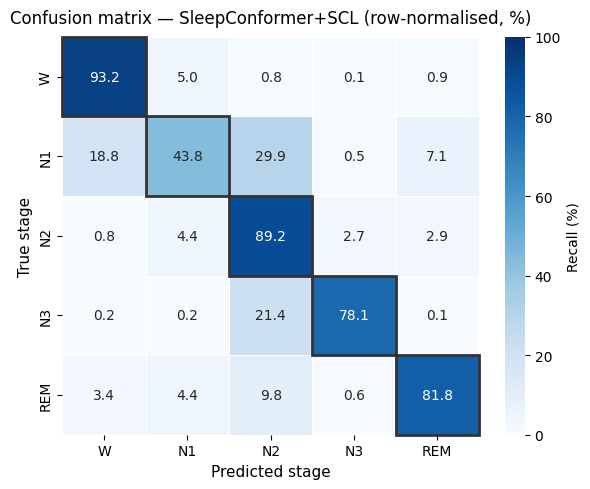

✓ Confusion matrix saved


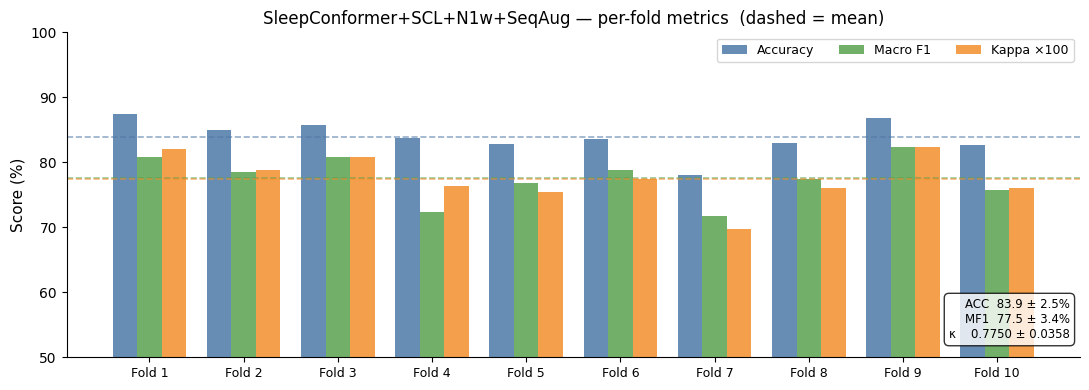

✓ Per-fold chart saved

Hypnogram: fold 1  (ACC=87.50%)


NameError: name 'SleepConformer' is not defined

In [15]:
# ════════════════════════════════════════════════════════════════
# CELL 14 — Visualization
#   1. Confusion matrix (normalized)
#   2. Per-fold ACC / MF1 / Kappa  (bar chart)
#   3. Sleep hypnogram — 1 record: predicted vs true
# ════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

STAGE_COLORS = {
    'W'  : '#4e79a7',
    'N1' : '#f28e2b',
    'N2' : '#59a14f',
    'N3' : '#e15759',
    'REM': '#b07aa1',
}
STAGE_LIST = ['W', 'N1', 'N2', 'N3', 'REM']

# ── Helper ───────────────────────────────────────────────────────
def _despine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ════════════════════════════════════════════════════════════════
# 1. CONFUSION MATRIX (row-normalized → recall per class)
# ════════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=(6, 5))

cm     = confusion_matrix(all_trues, all_preds, labels=list(range(N_CLASSES)))
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=STAGE_LIST, yticklabels=STAGE_LIST,
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Recall (%)'},
    ax=ax, vmin=0, vmax=100,
)
ax.set_xlabel('Predicted stage', fontsize=11)
ax.set_ylabel('True stage', fontsize=11)
ax.set_title('Confusion matrix — SleepConformer+SCL (row-normalised, %)', fontsize=12, pad=10)
ax.tick_params(axis='both', labelsize=10)

# Annotate diagonal (correct classifications)
for i in range(N_CLASSES):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                edgecolor='#333', lw=2, clip_on=False))

fig1.tight_layout()
fig1.savefig(OUT_DIR / 'cm_tcn.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Confusion matrix saved')


# ════════════════════════════════════════════════════════════════
# 2. PER-FOLD ACC / MF1 / KAPPA
# ════════════════════════════════════════════════════════════════
folds  = [m['fold']        for m in fold_metrics]
accs   = [m['acc']  * 100  for m in fold_metrics]
mf1s   = [m['mf1']  * 100  for m in fold_metrics]
kappas = [m['kappa'] * 100 for m in fold_metrics]

x      = np.arange(len(folds))
width  = 0.26

fig2, ax = plt.subplots(figsize=(11, 4))

b1 = ax.bar(x - width, accs,   width, label='Accuracy',  color='#4e79a7', alpha=0.85)
b2 = ax.bar(x,          mf1s,  width, label='Macro F1',  color='#59a14f', alpha=0.85)
b3 = ax.bar(x + width, kappas, width, label='Kappa ×100',color='#f28e2b', alpha=0.85)

# Mean lines
for vals, color in [(accs,'#4e79a7'),(mf1s,'#59a14f'),(kappas,'#f28e2b')]:
    ax.axhline(np.mean(vals), color=color, lw=1.2, ls='--', alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {f}' for f in folds], fontsize=9)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('SleepConformer+SCL+N1w+SeqAug — per-fold metrics  (dashed = mean)', fontsize=12)
ax.set_ylim(50, 100)
ax.legend(fontsize=9, ncol=3)
_despine(ax)

# Annotate mean ± std
stats_txt = (
    f"ACC  {np.mean(accs):.1f} ± {np.std(accs):.1f}%\n"
    f"MF1  {np.mean(mf1s):.1f} ± {np.std(mf1s):.1f}%\n"
    f"κ    {np.mean(kappas)/100:.4f} ± {np.std(kappas)/100:.4f}"
)
ax.text(0.99, 0.05, stats_txt, transform=ax.transAxes,
        fontsize=8.5, va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.8))

fig2.tight_layout()
fig2.savefig(OUT_DIR / 'per_fold_tcn.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Per-fold chart saved')


# ════════════════════════════════════════════════════════════════
# 3. SLEEP HYPNOGRAM — best fold, first test record
#    Tìm fold có ACC cao nhất, lấy record đầu tiên của test set
# ════════════════════════════════════════════════════════════════
best_fold_idx = int(np.argmax([m['acc'] for m in fold_metrics]))
best_fold     = fold_metrics[best_fold_idx]
print(f'\nHypnogram: fold {best_fold["fold"]}  '
      f'(ACC={best_fold["acc"]*100:.2f}%)')

# Load best-fold CNNs
fold_cnn_dir = CKPT_DIR / f'fold{best_fold["fold"]:02d}_cnn'
best_cnns    = {}
for ms in MANIP_SETS:
    mset = SET_TO_MSET[ms]
    for stage in SLEEP_STAGES:
        name = f'{mset}_{stage}'
        cnn  = SleepCNN().to(DEVICE)
        cnn.load_state_dict(torch.load(
            fold_cnn_dir / f'{name}.pth', map_location=DEVICE,
            weights_only=True))
        cnn.eval()
        best_cnns[name] = cnn

# Load best-fold TCN
best_tcn = SleepConformer(input_size=N_FEAT).to(DEVICE)
best_tcn.load_state_dict(torch.load(
    SEQ_CKPT_DIR / f'conformer_scl_seqaug_fold{best_fold["fold"]:02d}.pth',
    map_location=DEVICE, weights_only=True))
best_tcn.eval()

# Lấy test subjects của best fold và record đầu tiên
test_sids_best = list(fold_groups[best_fold_idx])
test_recs_best = [r for s in test_sids_best for r in subject_records[s]]

# Tìm record dài nhất để hypnogram đẹp hơn
rec = max(test_recs_best, key=lambda r: (r['lbls'] >= 0).sum())
n_valid = (rec['lbls'] >= 0).sum()
print(f'Record: {rec["fname"]}  ({n_valid} valid epochs)')

# Extract features và predict cho record đó
feat_rec = extract_features_for_records([rec], best_cnns)  # [(feats, lbls)]
feats, lbls = feat_rec[0]

with torch.no_grad():
    xb   = torch.from_numpy(feats.astype(np.float32)).unsqueeze(0).to(DEVICE)
    prob = best_tcn(xb).squeeze(0).cpu().numpy()  # (T, 5)
pred_all = prob.argmax(axis=1)                     # (T,)

# Filter valid epochs only
valid_mask = (lbls >= 0) & (lbls < N_CLASSES)
true_seq   = lbls[valid_mask]
pred_seq   = pred_all[valid_mask]
T          = len(true_seq)
time_hrs   = np.arange(T) * 30 / 3600   # convert epochs → hours

# Stage order on y-axis: W=0 top, REM=4 bottom (clinical convention)
# Flip so W is at top
STAGE_Y = {'W': 4, 'N1': 3, 'N2': 2, 'N3': 1, 'REM': 0}

fig3, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True,
                           gridspec_kw={'hspace': 0.08})

for ax_idx, (seq, title) in enumerate([
        (true_seq, 'True labels'),
        (pred_seq, 'SleepTCN predictions')]):
    ax = axes[ax_idx]

    # Draw colored segments
    for t in range(T):
        stage = STAGE_LIST[seq[t]]
        ax.fill_between(
            [time_hrs[t], time_hrs[t] + 30/3600],
            [STAGE_Y[stage] - 0.45, STAGE_Y[stage] - 0.45],
            [STAGE_Y[stage] + 0.45, STAGE_Y[stage] + 0.45],
            color=STAGE_COLORS[stage], alpha=0.85, linewidth=0
        )

    # Step line on top for readability
    step_y = [STAGE_Y[STAGE_LIST[s]] for s in seq]
    ax.step(time_hrs, step_y, where='post', color='#222', lw=0.8, alpha=0.5)

    ax.set_yticks(list(STAGE_Y.values()))
    ax.set_yticklabels(list(STAGE_Y.keys()), fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_ylim(-0.6, 4.6)
    ax.grid(axis='x', ls=':', lw=0.5, alpha=0.5)
    _despine(ax)

    # Shade N3 region lightly for emphasis
    ax.axhspan(-0.6, 1.45, color='#e15759', alpha=0.04)

axes[1].set_xlabel('Time (hours from recording start)', fontsize=11)

# Legend
patches = [mpatches.Patch(color=STAGE_COLORS[s], label=s) for s in STAGE_LIST]
axes[0].legend(handles=patches, ncol=5, fontsize=9,
               loc='upper right', framealpha=0.85)

# Title + accuracy for this record
rec_acc = (true_seq == pred_seq).mean() * 100
fig3.suptitle(
    f'Sleep hypnogram — {rec["fname"]}  '
    f'(epoch ACC = {rec_acc:.1f}%)',
    fontsize=12, y=1.01
)

fig3.tight_layout()
fig3.savefig(OUT_DIR / 'hypnogram_tcn.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Hypnogram saved  (record ACC={rec_acc:.1f}%)')
